In [16]:
from pathlib import Path

"""
Replace with your desired directories
"""

from utility import repo_root

FIG_DIR = Path("/Users/zach/2025_RA/matthias/final images/2_wake_vs_sleep_network")
FIG_DIR.mkdir(exist_ok=True, parents=True)
BIDS_DIR = Path("/Users/zach/2025_RA/matthias/bids_sleepmreye")
CONFIG_DIR = Path(repo_root() / "sleepmreye" / "designs")

In [17]:
from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root=BIDS_DIR,
    data_dir=BIDS_DIR / "derivatives" / "fmriprep",
    tr=2.1,
    task="sleep",
    desc_add="clean",
    load_eog=False
)

config = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"
print(desc_add)


clean-original-sleep-flame


In [18]:
from nilearn.glm import threshold_stats_img
import numpy as np

def network_summary(contrast, yeo_data, names, desc_add):
    data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)
    z_img     = data.t_stat
    brain_mask = data.mask 
    
    # FDR + cluster extent, computed once over the brain
    thr_map, thr = threshold_stats_img(
        data.z_stat , alpha=0.05, height_control="fdr",
        cluster_threshold=20, two_sided=True, mask_img=brain_mask,
    )
    
    z, sig = z_img.get_fdata(), thr_map.get_fdata() != 0
    out = {}
    for k, name in enumerate(names, start=1):
        print(k, name)
        m = yeo_data == k
        v, s = z[m], sig[m]
        out[name] = dict(mean_z=v.mean(), median_z=np.median(v),
                         pct_sig=100 * s.mean(),
                         rat_pos=(v > 0).mean(),#, / ((v < 0).mean() if (v < 0).mean() > 0 else 1),
                         std=v.std(),
                         )
    return out


In [19]:
from nilearn import image
from nilearn import datasets

network_names = ['Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']
contrasts = ("mreyemove_W", "mreyemove_S")

yeo = datasets.fetch_atlas_yeo_2011(n_networks=7, thickness="thick")
yeo_img = yeo.maps
contrast_map = {contrast: mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)[0].t_stat for contrast in contrasts}

yeo_resampled = image.resample_to_img(yeo_img, contrast_map[contrasts[0]], interpolation="nearest", force_resample=True, copy_header=True)
yeo_data = yeo_resampled.get_fdata() 
if yeo_data.ndim == 4:
    yeo_data = yeo_data[:,:,:,0]

wake_res  = network_summary("mreyemove_W",  yeo_data, network_names, desc_add)
sleep_res = network_summary("mreyemove_S", yeo_data, network_names, desc_add)


[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011
1 Visual
2 Somatomotor
3 Dorsal Attention
4 Ventral Attention
5 Limbic
6 Frontoparietal
7 Default
1 Visual
2 Somatomotor
3 Dorsal Attention
4 Ventral Attention
5 Limbic
6 Frontoparietal
7 Default



Stat: median_z
Network: Visual 
Wake: 2.6689494848251343, Sleep: 2.3755582571029663
Network: Dorsal Attention 
Wake: 0.1876019760966301, Sleep: 0.20205015689134598
Network: Ventral Attention 
Wake: 0.16427939385175705, Sleep: -1.0077237486839294
Network: Somatomotor 
Wake: 0.11270114034414291, Sleep: -0.5753300189971924
Network: Limbic 
Wake: 0.0, Sleep: 0.0
Network: Frontoparietal 
Wake: -1.30107843875885, Sleep: -2.046178102493286
Network: Default 
Wake: -1.5740758180618286, Sleep: -0.8459910750389099

Stat: pct_sig
Network: Visual 
Wake: 42.40275526742302, Sleep: 31.82739059967585
Network: Dorsal Attention 
Wake: 3.0419373892498522, Sleep: 4.48907265209687
Network: Ventral Attention 
Wake: 2.013201320132013, Sleep: 8.085808580858085
Network: Somatomotor 
Wake: 2.312800549576368, Sleep: 0.5037783375314862
Network: Limbic 
Wake: 0.0390625, Sleep: 0.0
Network: Frontoparietal 
Wake: 8.751431844215348, Sleep: 28.568155784650628
Network: Default 
Wake: 11.33898053202556, Sleep: 7.4305245

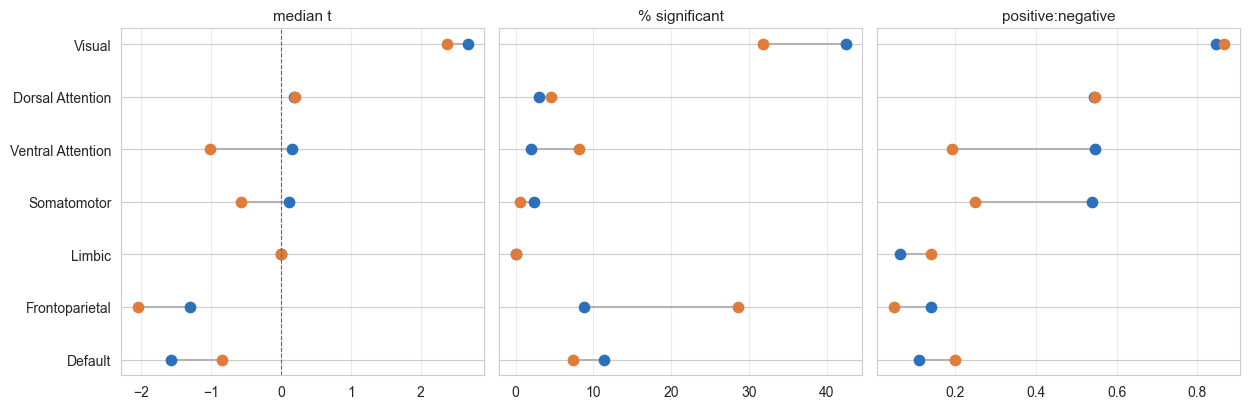

In [20]:
import numpy as np
import matplotlib.pyplot as plt

metrics = [
    ('median_z', 'median t', True),          # signed → zero line
    ('pct_sig', '% significant', False),
    # ('pct_pos_sig', '% positive | sig', False),
    # ('mean_z', 'mean z', True),          # signed → zero line
    # ("std", "std", False),
    ('rat_pos', 'positive:negative', False),
]

label_mapping = {
    
}
order = sorted(network_names, key=lambda n: wake_res[n]['median_z'], reverse=True)
y = np.arange(len(order))[::-1]                  # strongest at top
c_w, c_s = '#2C6FBB', '#E07B39'                  # wake, sleep

fig, axes = plt.subplots(1, len(metrics), figsize=(4.2 * len(metrics), 4.2),
                         sharey=True)

for ax, (key, label, signed) in zip(axes, metrics):
    print(f"\nStat: {key}")
    for yi, net in zip(y, order):
        w, s = wake_res[net][key], sleep_res[net][key]
        print(f"Network: {net} \nWake: {w}, Sleep: {s}")
        if np.isfinite(w) and np.isfinite(s):
            ax.plot([w, s], [yi, yi], color='0.7', lw=1.5, zorder=1)
        if np.isfinite(w):
            ax.scatter(w, yi, color=c_w, s=55, zorder=2)
        if np.isfinite(s):
            ax.scatter(s, yi, color=c_s, s=55, zorder=2)
    if signed:
        ax.axvline(0, color='0.4', lw=0.8, ls='--')
    ax.set_title(label, fontsize=11)
    ax.grid(axis='x', color='0.92'); ax.set_axisbelow(True)

axes[0].set_yticks(y); axes[0].set_yticklabels(order)
fig.tight_layout()
plt.savefig(FIG_DIR / "diffs.svg", dpi=300)
plt.show()

In [21]:
from mreyemove.analysis.glm.atlas import fetch_atlas
from mreyemove.plotting.glm_surface import plot_img_on_surf_with_contour
from mreyemove.plotting.glm import custom_cmap
import numpy as np

# Load Yeo 7 atlas and resample to cope space
surf_mesh = "fsaverage7"
yeo_surf = fetch_atlas("yeo_surf")
    
output_dir = FIG_DIR / "masks"
output_dir.mkdir(parents=True, exist_ok=True)

for i, name in enumerate(network_names):
    if name == "Somatomotor":
        continue
    idx = i + 1
    outside = (yeo_data != idx)

    for contrast in contrasts:
        # Mask the volume with the yeo network 
        t_img = contrast_map[contrast]
        
        
        roi_mask = {}
        for hemi in ("left", "right"):
            # Create a mask which is true within this ROI 
            hemi_data = yeo_surf.maps.data.parts[hemi].astype(np.float32)
            _mask = np.zeros_like(hemi_data)
            _mask[hemi_data == idx] = 1
            roi_mask[hemi] = _mask.astype(bool)

        plot_img_on_surf_with_contour(
            surf_mesh=surf_mesh,
            stat_map=t_img,
            mask=roi_mask,
            roi_map=yeo_surf.maps.data.parts,
            levels=[idx],
            labels=[name],
            contour_width=2,
            colors=["w"],
            vmin=-8, vmax=8,
            cmap=custom_cmap(),
            inflate=True,
            bg_on_data=True,
            legend=True,
            title=f"{name} for contrast {contrast}",
            output_file=output_dir / f"{name}_{contrast}",
        )

[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[check_mesh_is_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x13024d6c0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x320b5ac00> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [7]:
"""
Building neighbourhoods takes a while - just do it once
"""

from mreyemove.analysis.searchlight_correlation import build_fsaverage_neighborhoods
radius_mm = 23  # geodesic radius in mm
surf_mesh = "fsaverage7"

neighborhoods = build_fsaverage_neighborhoods(surf_mesh=surf_mesh, radius_mm=radius_mm)

[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Building geodesic neighborhoods (radius=23mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 830, Median: 787, Min: 254, Max: 2009
Building geodesic neighborhoods (radius=23mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 846, Median: 799, Min: 285, Max: 2059


In [14]:
from SleepMReye.plotting import plot_surface_searchlight
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation

from mreyemove.analysis.glm.atlas import fetch_atlas
import numpy as np

surf_mesh = "fsaverage7"
yeo_surf = fetch_atlas("yeo_surf")
    
output_dir = FIG_DIR / "masks"
output_dir.mkdir(parents=True, exist_ok=True)


data_a, _ = mrio.load_FLAME_result(contrast="mreyemove_W", desc_add=desc_add)
data_b, _ = mrio.load_FLAME_result(contrast="mreyemove_S", desc_add=desc_add)

corr_map, _ = run_fsaverage_surface_searchlight_correlation(
    data_b.t_stat, data_a.t_stat,
    surf_mesh=surf_mesh,
    neighborhoods=neighborhoods
)
    
for i, name in enumerate(network_names):
    if name in ("Visual", "Somatomotor"):
        continue
    idx = i + 1
    outside = (yeo_data != idx)

    roi_mask = {}
    for hemi in ("left", "right"):
        # Create a mask which is true within this ROI 
        hemi_data = yeo_surf.maps.data.parts[hemi].astype(np.float32)
        _mask = np.zeros_like(hemi_data)
        _mask[hemi_data == idx] = 1
        roi_mask[hemi] = _mask.astype(bool)
        
    plot_surface_searchlight(
        corr_map,
        surf_mesh=surf_mesh,
        inflate=True,
        mask=roi_mask,
        # threshold=0.3,
        title=f"{name} for contrast surface-based searchlight correlation",
        output_file=output_dir / f"{name}_searchlight_correlation",
    )


[load_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 60.8%
r_valid <= -0.3: 7.1%
n valid vertices = 163308
r_valid >=  0.3: 61.0%
r_valid <= -0.3: 7.1%
Median r: 0.4387204945087433
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 59.7%
r_valid <= -0.3: 9.3%
n valid vertices = 163775
r_valid >=  0.3: 59.7%
r_valid <= -0.3: 9.3%
Median r: 0.4277384579181671
Joint hemisphere median r: 0.4335213601589203
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
